In [119]:
from __future__ import annotations

from pathlib import Path
import re
from typing import Dict, Optional


def read_simulation_time(log_file: str | Path) -> Dict[str, Optional[float]]:
    """Read simulation timing information from an md-flexible logOutput file.

    Returns a dictionary with:
    - metric: Which line was parsed ("Total wall-clock time", "Simulate", or "Total accumulated")
    - nanoseconds: Parsed time in ns (float)
    - seconds: Parsed time in s (float)
    - file: Absolute path to the parsed file
    """
    path = Path(log_file).expanduser().resolve()
    text = path.read_text(encoding="utf-8", errors="replace")

    patterns = [
        r"Total wall-clock time\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
        r"Simulate\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
        r"Total accumulated\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
    ]
    labels = ["Total wall-clock time", "Simulate", "Total accumulated"]

    for label, pattern in zip(labels, patterns):
        match = re.search(pattern, text)
        if match:
            return {
                "metric": label,
                "nanoseconds": float(match.group(1)),
                "seconds": float(match.group(2)),
                "file": str(path),
            }

    raise ValueError(
        f"No known simulation-time pattern found in {path}. Expected one of: "
        "'Total wall-clock time', 'Simulate', or 'Total accumulated'."
    )


# Example:
# result = read_simulation_time(
#     "generated_inputs_gridFit/totalParticles_300000/sigmaRatio_0p15/countRatio_2p00/dataLayout_AoS/run_0/logOutput_155157_2.out"
# )
# print(result)


In [120]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats as scipy_stats
    _HAS_SCIPY = True
except Exception:
    scipy_stats = None
    _HAS_SCIPY = False


def infer_total_particles_from_input(run_dir: Path) -> int | None:
    """Infer total particles from input.yaml if not encoded in path."""
    input_yaml = run_dir / "input.yaml"
    if not input_yaml.exists():
        return None

    total = 0
    pattern = re.compile(r"numberOfParticles\s*:\s*([0-9]+)")
    for line in input_yaml.read_text(encoding="utf-8", errors="replace").splitlines():
        m = pattern.search(line)
        if m:
            total += int(m.group(1))
    return total if total > 0 else None


def infer_grid_fit_mode(parts: tuple[str, ...], include_legacy_modes: bool = False) -> str | None:
    """Infer whether a run belongs to fit-on or fit-off from path parts."""
    for token in parts:
        if token == "gridFitOn2":
            return "gridFitOn2"
        if token == "gridFitOff2":
            return "gridFitOff2"
        if include_legacy_modes and token == "gridFitOn":
            return "gridFitOn2"
        if include_legacy_modes and token == "gridFitOff":
            return "gridFitOff2"
    return None


def collect_runtime_data(base_dir: str | Path = ".", include_legacy_modes: bool = False) -> pd.DataFrame:
    """Collect simulation times from logOutput files under base_dir recursively."""
    base = Path(base_dir).expanduser().resolve()
    rows = []

    for log_path in base.rglob("logOutput_*.out"):
        parts = log_path.parts

        grid_fit = infer_grid_fit_mode(parts, include_legacy_modes=include_legacy_modes)
        if grid_fit is None:
            continue

        if not any(p.startswith("sigmaRatio_") for p in parts):
            continue
        if not any(p.startswith("dataLayout_") for p in parts):
            continue
        if not any(p.startswith("run_") for p in parts):
            continue

        sigma_ratio_str = next(p.split("_")[1] for p in parts if p.startswith("sigmaRatio_"))
        sigma_ratio = float(sigma_ratio_str.replace("p", "."))
        data_layout = next(p.split("_")[1] for p in parts if p.startswith("dataLayout_"))
        run = int(next(p.split("_")[1] for p in parts if p.startswith("run_")))

        total_dir = next((p for p in parts if p.startswith("totalParticles_")), None)
        if total_dir is not None:
            total_particles = int(total_dir.split("_")[1])
        else:
            total_particles = infer_total_particles_from_input(log_path.parent)
            if total_particles is None:
                continue

        timing = read_simulation_time(log_path)
        rows.append(
            {
                "grid_fit": grid_fit,
                "total_particles": total_particles,
                "sigma_ratio": sigma_ratio,
                "data_layout": data_layout,
                "run": run,
                "seconds": timing["seconds"],
                "log_file": str(log_path),
            }
        )

    return pd.DataFrame(rows)


def t_critical(confidence: float, dof: int) -> float:
    """Two-sided t critical value for a given central confidence and dof."""
    if dof <= 0:
        return 0.0

    p = (1.0 + confidence) / 2.0

    if _HAS_SCIPY:
        return float(scipy_stats.t.ppf(p, dof))

    z_lookup = {
        0.68: 0.994,
        0.86: 1.080,
        0.90: 1.645,
        0.95: 1.960,
        0.99: 2.576,
    }
    return z_lookup.get(round(confidence, 2), 1.96)


def apply_scrbook_11pt_style(use_latex=False):
    """Style settings tuned for thesis figures included at ~\\textwidth in scrbook 11pt."""
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 600,
            "font.size": 11,
            "axes.titlesize": 11,
            "axes.labelsize": 11,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 9,
            "legend.title_fontsize": 9,
            "lines.linewidth": 1.4,
            "lines.markersize": 4.5,
            "axes.grid": True,
            "grid.alpha": 0.3,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "text.usetex": use_latex,
        }

    )


def fitted_grid_transition_sigmas_from_last_cell(max_ratio: int = 13, dense_points: int = 20000) -> list[float]:
    """Read all fitted-grid transition positions in the plotted sigma range (fitted only)."""
    analysis_df = globals().get("df")
    if analysis_df is None:
        return []

    required = {"sigma_ratio", "num_levels", "higher_over_lower_true_x"}
    if not required.issubset(set(analysis_df.columns)):
        return []

    runtime = globals().get("runtime_df")
    if runtime is not None and not runtime.empty and "sigma_ratio" in runtime.columns:
        sigma_min = float(runtime["sigma_ratio"].min())
        sigma_max = float(runtime["sigma_ratio"].max())
    else:
        sigma_min = float(analysis_df["sigma_ratio"].min())
        sigma_max = float(analysis_df["sigma_ratio"].max())

    if "hgmatching_cell_sizes_both_modes" in globals():
        dense_sigmas = np.linspace(sigma_min, sigma_max, dense_points)
        dense_res = hgmatching_cell_sizes_both_modes(dense_sigmas)
        fitted = pd.DataFrame(
            {
                "sigma_ratio": [r["sigma_ratio"] for r in dense_res],
                "num_levels": [r["num_levels"] for r in dense_res],
                "ratio_true": [r["higher_cell_length"][0] / r["lower_cell_length_true"][0] for r in dense_res],
            }
        )
    else:
        fitted = analysis_df.rename(columns={"higher_over_lower_true_x": "ratio_true"})[
            ["sigma_ratio", "num_levels", "ratio_true"]
        ].copy()

    fitted = fitted.loc[fitted["num_levels"] >= 2].copy()
    if fitted.empty:
        return []

    fitted = fitted.sort_values("sigma_ratio").drop_duplicates(subset=["sigma_ratio"], keep="last")
    sigmas = fitted["sigma_ratio"].astype(float).to_numpy()
    ratios = fitted["ratio_true"].astype(float).to_numpy()

    transitions = []
    for i in range(len(sigmas) - 1):
        if abs(ratios[i + 1] - ratios[i]) > 1e-12 and ratios[i] <= max_ratio:
            transitions.append(float(0.5 * (sigmas[i] + sigmas[i + 1])))

    return transitions


def plot_runtime_vs_sigma(
    df: pd.DataFrame,
    data_layout: str,
    ax=None,
    error_mode: str = "t86",
    legend_loc: str = "best",
    grid_df: pd.DataFrame | None = None,
):
    """Plot mean runtime vs sigma ratio for one data layout with error bars."""
    subset = df[df["data_layout"].str.lower() == data_layout.lower()].copy()
    subset = subset[~subset["sigma_ratio"].round(2).eq(0.55)].copy()
    subset = subset[subset["total_particles"] != 1000].copy()
    if subset.empty:
        raise ValueError(f"No rows found for data_layout={data_layout!r}.")

    summary = (
        subset.groupby(["grid_fit", "total_particles", "sigma_ratio"], as_index=False)
        .agg(seconds_mean=("seconds", "mean"), seconds_std=("seconds", "std"), n=("seconds", "count"))
        .sort_values(["grid_fit", "total_particles", "sigma_ratio"])
    )

    summary["seconds_std"] = summary["seconds_std"].fillna(0.0)

    if error_mode == "std":
        summary["error"] = summary["seconds_std"]
    else:
        confidence = 0.86 if error_mode == "t86" else 0.95
        summary["se"] = summary["seconds_std"] / summary["n"].pow(0.5)
        summary["tcrit"] = summary["n"].apply(lambda n: t_critical(confidence, int(n - 1)))
        summary["error"] = summary["tcrit"] * summary["se"]

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4.5))

    unique_particles = sorted(summary["total_particles"].unique(), reverse=True)
    colors = plt.cm.tab10(range(len(unique_particles)))
    particle_color_map = {p: colors[i] for i, p in enumerate(unique_particles)}

    line_styles = {
        "gridFitOn": "-",
        "gridFitOff": "--",
        "gridFitOn2": "-",
        "gridFitOff2": "--",
    }
    mode_order = ["gridFitOn2", "gridFitOff2", "gridFitOn", "gridFitOff"]
    labeled_particles = set()
    for mode in mode_order:
        mode_subset = summary[summary["grid_fit"] == mode]
        for total_particles, grp in mode_subset.groupby("total_particles"):
            color = particle_color_map[total_particles]
            label = f"N={total_particles:,}".replace(",", " ") if total_particles not in labeled_particles else "_nolegend_"
            labeled_particles.add(total_particles)
            ax.errorbar(
                grp["sigma_ratio"],
                grp["seconds_mean"],
                yerr=grp["error"],
                marker="o",
                linestyle=line_styles.get(mode, "-"),
                capsize=3,
                color=color,
                label=label,
            )

    # Draw vertical lines at exact sigma datapoints where fitOff and fitOn have matching cells-per-higher-cell.
    if grid_df is not None:
        required_cols = {"sigma_ratio", "higher_over_lower_false_x", "higher_over_lower_true_x"}
        if required_cols.issubset(set(grid_df.columns)):
            grid_data = grid_df.sort_values("sigma_ratio")[["sigma_ratio", "higher_over_lower_false_x", "higher_over_lower_true_x"]].copy()
            grid_data = grid_data.dropna(subset=["higher_over_lower_false_x", "higher_over_lower_true_x"])

            if not grid_data.empty:
                equal_mask = (grid_data["higher_over_lower_false_x"] - grid_data["higher_over_lower_true_x"]).abs() <= 1e-12
                matching_sigmas = grid_data.loc[equal_mask, "sigma_ratio"].astype(float).tolist()

                for sigma in matching_sigmas:
                    ax.axvline(x=sigma, color="0.35", linestyle=":", linewidth=0.9, alpha=0.8, zorder=0)

    ax.set_title(f"Runtime vs Sigma Ratio ({data_layout.upper()})")
    ax.set_xlabel(r"Cutoff ratio $r_{c_0} / r_{c_1}$")
    ax.set_ylabel(r"Simulation time $t$ in s")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    handles, labels = ax.get_legend_handles_labels()
    order = sorted(
        range(len(labels)),
        key=lambda i: int(labels[i].split("=")[1].replace(" ", "")) if labels[i].startswith("N=") else -1,
        reverse=True,
    )
    ax.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        title="Particle count",
        fontsize=9,
        loc=legend_loc,
    )


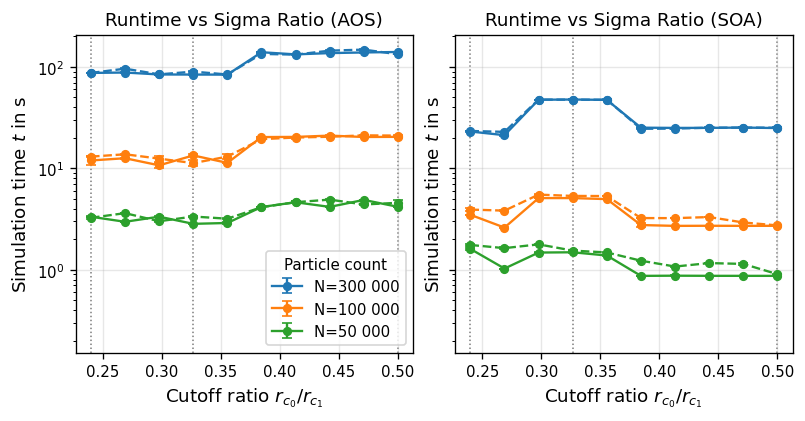

Plot mapping: solid line (-) = gridFitOn2, dashed line (--) = gridFitOff2.
Saved: ../thesis_plots/gridFit.pdf
Vertical markers shown where fitOff and fitOn have equal cells-per-higher-cell.


In [121]:
# Collect data and generate one export-ready figure
runtime_df = collect_runtime_data(".", include_legacy_modes=False)
runtime_df = runtime_df[runtime_df["total_particles"] != 1000].copy()

# Vertical grid markers are only available after the grid-analysis cell has been run.
grid_df_for_markers = globals().get("df")

# If your LaTeX setup has full TeX support for Matplotlib, set this to True.
apply_scrbook_11pt_style(use_latex=False)

if runtime_df.empty:
    print("No logOutput_*.out files found below current directory.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(6.6, 3.4), sharey=True, constrained_layout=True)
    plot_runtime_vs_sigma(
        runtime_df,
        "AoS",
        ax=axes[0],
        error_mode="t86",
        legend_loc="lower right",
        grid_df=grid_df_for_markers,
    )
    plot_runtime_vs_sigma(runtime_df, "SoA", ax=axes[1], error_mode="t86", grid_df=grid_df_for_markers)

    right_legend = axes[1].get_legend()
    if right_legend is not None:
        right_legend.remove()

    output_dir = Path("..") / "thesis_plots"
    output_dir.mkdir(exist_ok=True)

    pdf_path = output_dir / "gridFit.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()
    print("Plot mapping: solid line (-) = gridFitOn2, dashed line (--) = gridFitOff2.")
    print(f"Saved: {pdf_path}")
    if grid_df_for_markers is None:
        print("No vertical markers: run Cell 5 first to populate 'df'.")
    else:
        print("Vertical markers shown where fitOff and fitOn have equal cells-per-higher-cell.")


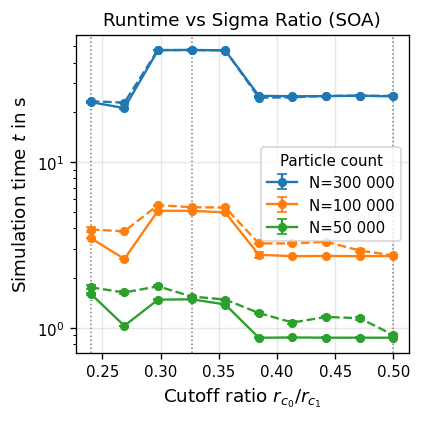

Saved: ../thesis_plots/gridFit_SoA_only.pdf


In [122]:
# SoA-only plot (new figure)
if "runtime_df" not in globals() or runtime_df is None or runtime_df.empty:
    runtime_df = collect_runtime_data(".", include_legacy_modes=False)
    runtime_df = runtime_df[runtime_df["total_particles"] != 1000].copy()

grid_df_for_markers = globals().get("df")

fig, ax = plt.subplots(1, 1, figsize=(3.4, 3.4), constrained_layout=True)
plot_runtime_vs_sigma(runtime_df, "SoA", ax=ax, error_mode="t86", grid_df=grid_df_for_markers)

output_dir = Path("..") / "thesis_plots"
output_dir.mkdir(exist_ok=True)
soa_pdf_path = output_dir / "gridFit_SoA_only.pdf"
fig.savefig(soa_pdf_path, bbox_inches="tight")

plt.show()
print(f"Saved: {soa_pdf_path}")
if grid_df_for_markers is None:
    print("No vertical markers: run Cell 5 first to populate 'df'.")


In [123]:
import math
import numpy as np
import pandas as pd


def _cellblock3d_cell_length(box_min, box_max, interaction_length, cell_size_factor=1.0):
    """Mirror CellBlock3D::rebuild for the constructor that takes cellSizeFactor."""
    box_min = np.asarray(box_min, dtype=float)
    box_max = np.asarray(box_max, dtype=float)
    box_lengths = box_max - box_min

    # CellBlock3D behavior for csf >= 1.0 / < 1.0 only affects halo width, not owned cell length.
    cells_per_dim = np.maximum(np.floor(box_lengths / (interaction_length * cell_size_factor)).astype(int), 1)
    cell_length = box_lengths / cells_per_dim
    return cell_length, cells_per_dim


def _cellblock3d_cell_length_from_cells_per_dim(box_min, box_max, cells_per_dim):
    """Mirror CellBlock3D::rebuild for the constructor that takes cellsPerDimension."""
    box_min = np.asarray(box_min, dtype=float)
    box_max = np.asarray(box_max, dtype=float)
    box_lengths = box_max - box_min
    cells_per_dim = np.asarray(cells_per_dim, dtype=int)
    cell_length = box_lengths / cells_per_dim
    return cell_length, cells_per_dim


def hgmatching_cell_sizes_both_modes(
    sigma_ratios,
    box_min=(0.0, 0.0, 0.0),
    box_max=(20.0, 20.0, 20.0),
    skin=0.1,
    higher_cutoff=3.0,
    cell_size_factor=1.0,
    sigma_max=1.0,
    cutoff_scale=3.0,
    use_generator_rounding=True,
):
    """
    Mimic HierarchicalGridMatching + LinkedCells + CellBlock3D for both fittedGrids=false and fittedGrids=true.

    Returns per sigma ratio:
    - higher cell length
    - lower cell length for fittedGrids=false (ratio-based csf)
    - lower cell length for fittedGrids=true (cellsPerDimension path)
    - lowerCellsPerHigher check values
    """
    box_min = np.asarray(box_min, dtype=float)
    box_max = np.asarray(box_max, dtype=float)

    max_length = float(np.min(box_max - box_min) - skin)
    out = []

    for sigma_ratio in sigma_ratios:
        sigma0 = sigma_max * float(sigma_ratio)
        cutoff0 = cutoff_scale * sigma0
        if use_generator_rounding:
            # input_generator writes cutoff0 with 6 decimals.
            cutoff0 = float(f"{cutoff0:.6f}")

        # Mimic constructor preprocessing: clamp > maxLength, sort, unique.
        cutoffs = sorted({min(cutoff0, max_length), min(higher_cutoff, max_length)})

        # Highest level (always constructed first with cellSizeFactor).
        highest_interaction = cutoffs[-1] + skin
        higher_cell_length, higher_cells_per_dim = _cellblock3d_cell_length(
            box_min, box_max, highest_interaction, cell_size_factor
        )

        # If lower cutoff collapsed away through uniqueness, only one level exists.
        if len(cutoffs) < 2:
            out.append(
                {
                    "sigma_ratio": float(sigma_ratio),
                    "num_levels": 1,
                    "lower_cells_per_higher": np.array([np.nan, np.nan, np.nan]),
                    "higher_cell_length": higher_cell_length.copy(),
                    "lower_cell_length_false": higher_cell_length.copy(),
                    "lower_cell_length_true": higher_cell_length.copy(),
                }
            )
            continue

        lower_interaction = cutoffs[0] + skin

        # Pre-check in HierarchicalGridMatching before branch on fittedGrids.
        lower_cells_per_higher = np.floor(higher_cell_length / (lower_interaction * cell_size_factor)).astype(int)
        if np.any(lower_cells_per_higher < 2):
            # Level removed, hierarchy degenerates to highest level only.
            out.append(
                {
                    "sigma_ratio": float(sigma_ratio),
                    "num_levels": 1,
                    "lower_cells_per_higher": lower_cells_per_higher.copy(),
                    "higher_cell_length": higher_cell_length.copy(),
                    "lower_cell_length_false": higher_cell_length.copy(),
                    "lower_cell_length_true": higher_cell_length.copy(),
                }
            )
            continue

        # fittedGrids == false branch: ratio-based cellSizeFactor for lower level.
        ratio = lower_interaction / highest_interaction
        lower_csf = cell_size_factor * ratio
        lower_cell_length_false, _ = _cellblock3d_cell_length(box_min, box_max, highest_interaction, lower_csf)

        # fittedGrids == true branch: explicitly matched cellsPerDimension.
        lower_cells_per_dim_true = lower_cells_per_higher * higher_cells_per_dim
        lower_cell_length_true, _ = _cellblock3d_cell_length_from_cells_per_dim(
            box_min, box_max, lower_cells_per_dim_true
        )

        out.append(
            {
                "sigma_ratio": float(sigma_ratio),
                "num_levels": 2,
                "lower_cells_per_higher": lower_cells_per_higher.copy(),
                "higher_cell_length": higher_cell_length.copy(),
                "lower_cell_length_false": lower_cell_length_false.copy(),
                "lower_cell_length_true": lower_cell_length_true.copy(),
            }
        )

    return out


# Example on your current gridFit sigma ratios.
#sigmas = np.linspace(0.24, 0.50, 10)
sigmas = [0.24, 0.268889, 0.297778, 0.326667, 0.355556, 0.384444, 0.413333, 0.442222, 0.471111, 0.5]
res = hgmatching_cell_sizes_both_modes(sigmas)

df = pd.DataFrame(
    {
        "sigma_ratio": [r["sigma_ratio"] for r in res],
        "num_levels": [r["num_levels"] for r in res],
        "lower_cells_per_higher_x": [
            (int(r["lower_cells_per_higher"][0]) if not np.isnan(r["lower_cells_per_higher"][0]) else np.nan)
            for r in res
        ],
        "higher_cell_length_x": [r["higher_cell_length"][0] for r in res],
        "higher_over_lower_false_x": [r["higher_cell_length"][0] / r["lower_cell_length_false"][0] for r in res],
        "higher_over_lower_true_x": [r["higher_cell_length"][0] / r["lower_cell_length_true"][0] for r in res],
    }
)

df

,sigma_ratio,num_levels,lower_cells_per_higher_x,higher_cell_length_x,higher_over_lower_false_x,higher_over_lower_true_x
0,0.240000,2,4,3.333333,4.000000,4.0
1,0.268889,2,3,3.333333,3.666667,3.0
2,0.297778,2,3,3.333333,3.333333,3.0
3,0.326667,2,3,3.333333,3.000000,3.0
4,0.355556,2,2,3.333333,2.833333,2.0
5,0.384444,2,2,3.333333,2.500000,2.0
6,0.413333,2,2,3.333333,2.333333,2.0
7,0.442222,2,2,3.333333,2.333333,2.0
8,0.471111,2,2,3.333333,2.166667,2.0
9,0.500000,2,2,3.333333,2.000000,2.0


In [124]:
# Debug: Check grid transition points
print("Grid data with lower_cells_per_higher_x:")
print(df[["sigma_ratio", "lower_cells_per_higher_x"]])

print("\nTransition points (where lower_cells_per_higher_x changes):")
grid_data = df.sort_values("sigma_ratio")[["sigma_ratio", "lower_cells_per_higher_x"]].copy()
grid_data = grid_data.dropna(subset=["lower_cells_per_higher_x"])

if len(grid_data) > 1:
    cells_values = grid_data["lower_cells_per_higher_x"].values
    sigmas_values = grid_data["sigma_ratio"].values
    
    transitions = []
    for i in range(len(cells_values) - 1):
        if cells_values[i] != cells_values[i + 1]:
            sigma = float(0.5 * (sigmas_values[i] + sigmas_values[i + 1]))
            transitions.append(sigma)
            print(f"  σ={sigmas_values[i]:.6f} (cells={cells_values[i]:.0f}) → σ={sigmas_values[i+1]:.6f} (cells={cells_values[i+1]:.0f})")
            print(f"    → Midpoint: σ={sigma:.6f}")
    
    if transitions:
        print(f"\nVertical line x-positions: {transitions}")
    else:
        print("\nNo transitions found in this sigma range!")
else:
    print("Not enough data points!")

Grid data with lower_cells_per_higher_x:
   sigma_ratio  lower_cells_per_higher_x
0     0.240000                         4
1     0.268889                         3
2     0.297778                         3
3     0.326667                         3
4     0.355556                         2
5     0.384444                         2
6     0.413333                         2
7     0.442222                         2
8     0.471111                         2
9     0.500000                         2

Transition points (where lower_cells_per_higher_x changes):
  σ=0.240000 (cells=4) → σ=0.268889 (cells=3)
    → Midpoint: σ=0.254444
  σ=0.326667 (cells=3) → σ=0.355556 (cells=2)
    → Midpoint: σ=0.341112

Vertical line x-positions: [0.25444449999999996, 0.3411115]


In [127]:
# Compare gridFitOn2 vs gridFitOff2 only at sigma points where fitted and non-fitted grids match.
if "runtime_df" not in globals() or runtime_df is None or runtime_df.empty:
    runtime_df = collect_runtime_data(".")
    runtime_df = runtime_df[runtime_df["total_particles"] != 1000].copy()

if "df" not in globals() or df is None or df.empty:
    raise RuntimeError("Grid analysis dataframe 'df' is not available. Run Cell 5 first.")

required_cols = {"sigma_ratio", "higher_over_lower_false_x", "higher_over_lower_true_x"}
if not required_cols.issubset(set(df.columns)):
    raise RuntimeError("Grid analysis dataframe 'df' misses required columns for matching-grid analysis.")

# Exact sigma points where both grid constructions yield identical cells-per-higher-cell ratio.
matching_sigmas = (
    df.loc[(df["higher_over_lower_false_x"] - df["higher_over_lower_true_x"]).abs() <= 1e-12, "sigma_ratio"]
    .astype(float)
    .sort_values()
    .tolist()
)

print(f"Matching-grid sigma points: {matching_sigmas}")

if not matching_sigmas:
    print("No matching-grid sigma points found.")
else:
    comp = runtime_df.copy()
    comp = comp[comp["sigma_ratio"].isin(matching_sigmas)].copy()

    summary = (
        comp.groupby(["data_layout", "total_particles", "sigma_ratio", "grid_fit"], as_index=False)
        .agg(seconds_mean=("seconds", "mean"), n=("seconds", "count"))
    )

    pivot = (
        summary.pivot_table(
            index=["data_layout", "total_particles", "sigma_ratio"],
            columns="grid_fit",
            values="seconds_mean",
            aggfunc="first",
        )
        .reset_index()
    )

    modes = {"gridFitOn2", "gridFitOff2"}
    if not modes.issubset(set(pivot.columns)):
        print("Could not compare both algorithms at matching-grid points: missing gridFitOn2 or gridFitOff2 data.")
    else:
        result = pivot.dropna(subset=["gridFitOn2", "gridFitOff2"]).copy()

        if result.empty:
            print("No comparable runtime points found at matching-grid sigmas.")
        else:
            result["faster_algorithm"] = result.apply(
                lambda r: "gridFitOn2" if r["gridFitOn2"] < r["gridFitOff2"] else "gridFitOff2",
                axis=1,
            )
            result["faster_time_s"] = result[["gridFitOn2", "gridFitOff2"]].min(axis=1)
            result["slower_time_s"] = result[["gridFitOn2", "gridFitOff2"]].max(axis=1)
            result["diff_s"] = result["slower_time_s"] - result["faster_time_s"]
            result["diff_pct_vs_slower"] = 100.0 * result["diff_s"] / result["slower_time_s"]

            detailed = result[
                [
                    "data_layout",
                    "total_particles",
                    "sigma_ratio",
                    "gridFitOn2",
                    "gridFitOff2",
                    "faster_algorithm",
                    "diff_s",
                    "diff_pct_vs_slower",
                ]
            ].sort_values(["sigma_ratio", "data_layout", "total_particles"])

            print("\nPer comparable point at matching-grid sigmas:")
            display(detailed)

            overall = (
                detailed.groupby("faster_algorithm", as_index=False)
                .agg(
                    points_won=("faster_algorithm", "count"),
                    mean_diff_s=("diff_s", "mean"),
                    mean_diff_pct=("diff_pct_vs_slower", "mean"),
                )
                .sort_values("points_won", ascending=False)
            )

            print("\nOverall summary at matching-grid sigmas:")
            display(overall)

    # Mean relative speedup using paired runs: speedup = without / with = gridFitOff2 / gridFitOn2.
    paired = comp[comp["grid_fit"].isin(["gridFitOn2", "gridFitOff2"])].groupby(
        ["data_layout", "total_particles", "sigma_ratio", "run", "grid_fit"], as_index=False
    ).agg(seconds=("seconds", "mean"))

    paired_pivot = paired.pivot_table(
        index=["data_layout", "total_particles", "sigma_ratio", "run"],
        columns="grid_fit",
        values="seconds",
        aggfunc="first",
    ).dropna(subset=["gridFitOn2", "gridFitOff2"]).reset_index()

    if paired_pivot.empty:
        print("No paired runs available to compute relative speedup.")
    else:
        paired_pivot["speedup_factor"] = paired_pivot["gridFitOff2"] / paired_pivot["gridFitOn2"]
        paired_pivot["speedup_pct"] = (paired_pivot["speedup_factor"] - 1.0) * 100.0

        n = len(paired_pivot)
        mean_factor = float(paired_pivot["speedup_factor"].mean())
        std_factor = float(paired_pivot["speedup_factor"].std(ddof=1)) if n > 1 else 0.0
        se_factor = std_factor / (n ** 0.5) if n > 1 else 0.0

        # One-sigma central interval via Student-t (68% confidence).
        tcrit_1sigma = t_critical(0.68, n - 1) if n > 1 else 0.0
        err_factor = tcrit_1sigma * se_factor

        mean_pct = (mean_factor - 1.0) * 100.0
        err_pct = err_factor * 100.0

        print("\nMean relative speedup (with gridFitOn2 as opposed to gridFitOff2):")
        print(f"Paired samples: n={n}")
        print(f"Speedup factor = t_off / t_on = {mean_factor:.6f} +- {err_factor:.6f} (Student-t, 1 sigma)")
        print(f"Relative speedup = {mean_pct:.3f}% +- {err_pct:.3f}% (Student-t, 1 sigma)")

        layout_stats = []
        for layout, grp in paired_pivot.groupby("data_layout"):
            n_l = len(grp)
            mean_factor_l = float(grp["speedup_factor"].mean())
            std_factor_l = float(grp["speedup_factor"].std(ddof=1)) if n_l > 1 else 0.0
            se_factor_l = std_factor_l / (n_l ** 0.5) if n_l > 1 else 0.0
            tcrit_l = t_critical(0.68, n_l - 1) if n_l > 1 else 0.0
            err_factor_l = tcrit_l * se_factor_l

            mean_pct_l = (mean_factor_l - 1.0) * 100.0
            err_pct_l = err_factor_l * 100.0

            print(
                f"{layout}: speedup factor = {mean_factor_l:.6f} +- {err_factor_l:.6f}, "
                f"relative speedup = {mean_pct_l:.3f}% +- {err_pct_l:.3f}% (n={n_l})"
            )

            layout_stats.append(
                {
                    "data_layout": layout,
                    "n": n_l,
                    "mean_speedup_factor": mean_factor_l,
                    "speedup_factor_err_1sigma": err_factor_l,
                    "mean_speedup_pct": mean_pct_l,
                    "speedup_pct_err_1sigma": err_pct_l,
                }
            )

        print("\nBy layout summary:")
        display(pd.DataFrame(layout_stats).sort_values("data_layout"))

        display(
            paired_pivot[
                ["data_layout", "total_particles", "sigma_ratio", "run", "speedup_factor", "speedup_pct"]
            ].sort_values(["sigma_ratio", "data_layout", "total_particles", "run"])
        )


Matching-grid sigma points: [0.24, 0.326667, 0.5]

Per comparable point at matching-grid sigmas:


grid_fit,data_layout,total_particles,sigma_ratio,gridFitOn2,gridFitOff2,faster_algorithm,diff_s,diff_pct_vs_slower
0,AoS,50000,0.240000,3.333667,3.255000,gridFitOff2,0.078667,2.359764
3,AoS,100000,0.240000,11.959333,13.046667,gridFitOn2,1.087333,8.334185
6,AoS,300000,0.240000,87.224000,87.248667,gridFitOn2,0.024667,0.028272
9,SoA,50000,0.240000,1.605333,1.756667,gridFitOn2,0.151333,8.614801
12,SoA,100000,0.240000,3.483333,3.923000,gridFitOn2,0.439667,11.207409
15,SoA,300000,0.240000,23.070333,23.363000,gridFitOn2,0.292667,1.252693
1,AoS,50000,0.326667,2.837333,3.349333,gridFitOn2,0.512000,15.286624
4,AoS,100000,0.326667,13.406667,11.256667,gridFitOff2,2.150000,16.036798
7,AoS,300000,0.326667,84.061333,89.851667,gridFitOn2,5.790333,6.444325
10,SoA,50000,0.326667,1.487667,1.545333,gridFitOn2,0.057667,3.731665



Overall summary at matching-grid sigmas:


,faster_algorithm,points_won,mean_diff_s,mean_diff_pct
1,gridFitOn2,14,0.703000,5.472401
0,gridFitOff2,4,2.405917,5.985827



Mean relative speedup (with gridFitOn2 as opposed to gridFitOff2):
Paired samples: n=54
Speedup factor = t_off / t_on = 1.033734 +- 0.010507 (Student-t, 1 sigma)
Relative speedup = 3.373% +- 1.051% (Student-t, 1 sigma)
AoS: speedup factor = 1.025896 +- 0.019528, relative speedup = 2.590% +- 1.953% (n=27)
SoA: speedup factor = 1.041572 +- 0.008535, relative speedup = 4.157% +- 0.853% (n=27)

By layout summary:


,data_layout,n,mean_speedup_factor,speedup_factor_err_1sigma,mean_speedup_pct,speedup_pct_err_1sigma
0,AoS,27,1.025896,0.019528,2.589600,1.952777
1,SoA,27,1.041572,0.008535,4.157197,0.853462


grid_fit,data_layout,total_particles,sigma_ratio,run,speedup_factor,speedup_pct
0,AoS,50000,0.240000,0,0.991629,-0.837070
1,AoS,50000,0.240000,1,0.961399,-3.860072
2,AoS,50000,0.240000,2,0.976048,-2.395210
9,AoS,100000,0.240000,0,1.021659,2.165895
10,AoS,100000,0.240000,1,1.085258,8.525784
11,AoS,100000,0.240000,2,1.176950,17.694952
18,AoS,300000,0.240000,0,1.001708,0.170813
19,AoS,300000,0.240000,1,0.999186,-0.081445
20,AoS,300000,0.240000,2,0.999954,-0.004584
27,SoA,50000,0.240000,0,1.086575,8.657465
